# March Machine Learning Mania 2026 — Full Walkthrough

**Goal:** Predict win probabilities for every possible matchup in both the Men's and Women's 2026 NCAA basketball tournaments.

**Metric:** Mean Squared Error (Brier score) — lower is better. Overconfident predictions (near 0 or 1) are heavily penalized when wrong.

**Competition:** [Kaggle — March Machine Learning Mania 2026](https://www.kaggle.com/competitions/march-machine-learning-mania-2026)

This notebook walks through the complete journey — from raw data to our final optimized model — showing *what* we tried, *why* it worked (or didn't), and the key insights we discovered along the way.

---

## Table of Contents

1. [Setup & Data Loading](#1)
2. [Exploratory Data Analysis](#2)
3. [Feature Engineering](#3)
4. [The Modeling Journey](#4)
   - 4.1 Baseline: Logistic Regression with 4 features
   - 4.2 Adding Elo ratings
   - 4.3 Splitting Men's vs Women's models
   - 4.4 Feature ablation & regularization tuning
   - 4.5 The 3-model ensemble
5. [What Didn't Work (And Why)](#5)
6. [Final Model & Feature Importance](#6)
7. [Generating Predictions](#7)
8. [Key Takeaways](#8)

<a id='1'></a>
## 1. Setup & Data Loading

We use a modular `src/` package built specifically for this competition. All raw CSVs live in `data/` and are never modified.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, log_loss
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Add project root to path so we can import src/
sys.path.insert(0, str(Path(".").resolve().parent))
from src import data_loader, features

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="muted")

print("Setup complete.")

Setup complete.


### Load raw data

Kaggle provides separate files for men's (`M*.csv`) and women's (`W*.csv`) data. Our `data_loader` module combines them automatically.

In [2]:
# Load all data sources
regular_season = data_loader.load_regular_season()   # Detailed box scores
tourney_results = data_loader.load_tourney_results()  # Tournament box scores
seeds = data_loader.load_tourney_seeds()              # Tournament seedings
compact_results = data_loader.load_compact_results()  # Scores only (for Elo)
teams = data_loader.load_teams()                      # Team ID <-> Name

print(f"Regular season games:  {len(regular_season):,}")
print(f"Tournament games:      {len(tourney_results):,}")
print(f"Tournament seeds:      {len(seeds):,}")
print(f"Compact results:       {len(compact_results):,}")
print(f"Teams:                 {len(teams):,}")
print(f"\nSeasons available:     {regular_season['Season'].min()} – {regular_season['Season'].max()}")

Regular season games:  211,716
Tournament games:      2,410
Tournament seeds:      4,506
Compact results:       341,084
Teams:                 760

Seasons available:     2003 – 2026


In [3]:
# What does a raw game look like?
regular_season.head(3)

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23


In [4]:
# Seeds: "W01" = West region, 1-seed. We parse the numeric seed.
seeds.head(5)

,Season,Seed,TeamID,seed
0,1985,W01,1207,1
1,1985,W02,1210,2
2,1985,W03,1228,3
3,1985,W04,1260,4
4,1985,W05,1374,5


### Key data decisions

- **Filter to 2010+** — Women's detailed stats start in 2010, so we use 2010 onward for consistent features across both genders.
- **Skip 2020** — COVID cancelled the tournament. No labels to train on.
- **Men's IDs < 3000, Women's IDs ≥ 3000** — this lets us split M/W cleanly.

In [5]:
# Filter to 2010+ for training
regular_season = regular_season[regular_season["Season"] >= 2010].copy()
tourney_results = tourney_results[tourney_results["Season"] >= 2010].copy()

# How much training data do we actually have?
tourney_no2020 = tourney_results[tourney_results["Season"] != 2020]
n_men = len(tourney_no2020[tourney_no2020["WTeamID"] < 3000])
n_women = len(tourney_no2020[tourney_no2020["WTeamID"] >= 3000])
print(f"Tournament games (2010–2025, excl. 2020):")
print(f"  Men's:   {n_men}")
print(f"  Women's: {n_women}")
print(f"  Total:   {n_men + n_women}")
print(f"\n⚠️  This is our ENTIRE training set. ~1,960 games is tiny.")
print(f"   This fundamentally constrains model complexity.")

Tournament games (2010–2025, excl. 2020):
  Men's:   1001
  Women's: 961
  Total:   1962

⚠️  This is our ENTIRE training set. ~1,960 games is tiny.
   This fundamentally constrains model complexity.


<a id='2'></a>
## 2. Exploratory Data Analysis

Before building features, let's understand the data and what makes tournament games different.

In [6]:
# How predictable is the tournament by seed alone?
tourney_seeds = tourney_no2020.merge(
    seeds[["Season", "TeamID", "seed"]].rename(columns={"TeamID": "WTeamID", "seed": "WSeed"}),
    on=["Season", "WTeamID"], how="left"
).merge(
    seeds[["Season", "TeamID", "seed"]].rename(columns={"TeamID": "LTeamID", "seed": "LSeed"}),
    on=["Season", "LTeamID"], how="left"
)
tourney_seeds["better_seed_won"] = tourney_seeds["WSeed"] <= tourney_seeds["LSeed"]

# Men's vs Women's
ts_men = tourney_seeds[tourney_seeds["WTeamID"] < 3000]
ts_women = tourney_seeds[tourney_seeds["WTeamID"] >= 3000]

print(f"Better seed wins:")
print(f"  Men's:   {ts_men['better_seed_won'].mean():.1%}")
print(f"  Women's: {ts_women['better_seed_won'].mean():.1%}")
print(f"\n→ Women's tournament is significantly more predictable (fewer upsets).")
print(f"  This is a KEY insight — we'll exploit it with separate models.")

Better seed wins:
  Men's:   72.6%
  Women's: 79.5%

→ Women's tournament is significantly more predictable (fewer upsets).
  This is a KEY insight — we'll exploit it with separate models.


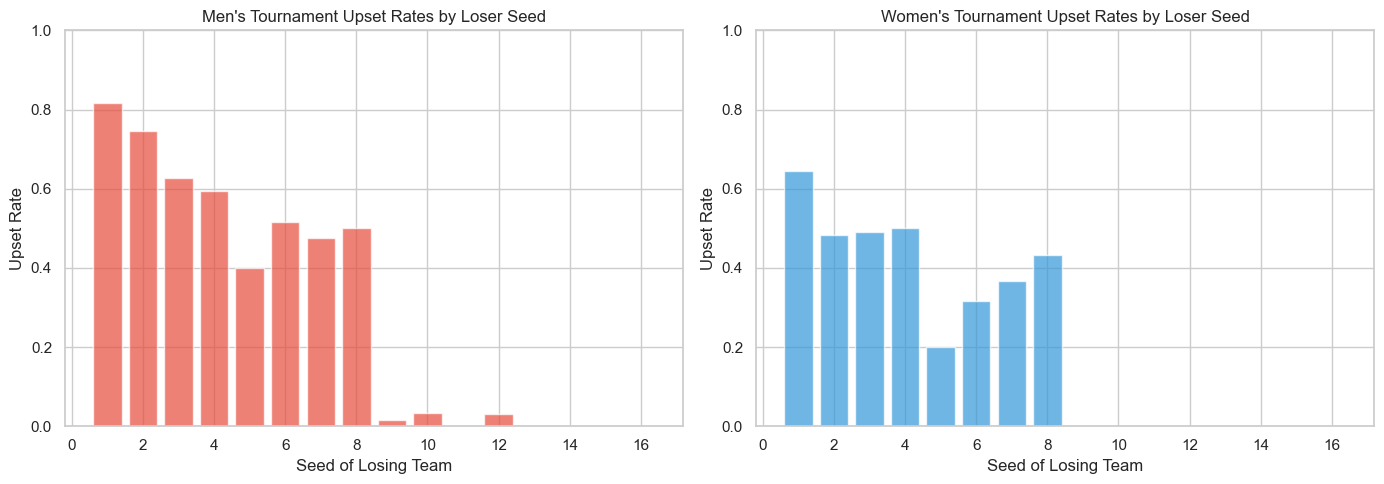

In [7]:
# Upset rates by seed matchup difference
tourney_seeds["seed_diff"] = tourney_seeds["WSeed"] - tourney_seeds["LSeed"]
tourney_seeds["is_mens"] = tourney_seeds["WTeamID"] < 3000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, df) in zip(axes, [("Men's", ts_men), ("Women's", ts_women)]):
    upset_rates = df.groupby("LSeed")["better_seed_won"].agg(["mean", "count"]).reset_index()
    upset_rates.columns = ["Losing Seed", "Win Rate (better seed)", "Games"]
    ax.bar(upset_rates["Losing Seed"], 1 - upset_rates["Win Rate (better seed)"],
           color="#e74c3c" if label == "Men's" else "#3498db", alpha=0.7)
    ax.set_xlabel("Seed of Losing Team")
    ax.set_ylabel("Upset Rate")
    ax.set_title(f"{label} Tournament Upset Rates by Loser Seed")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

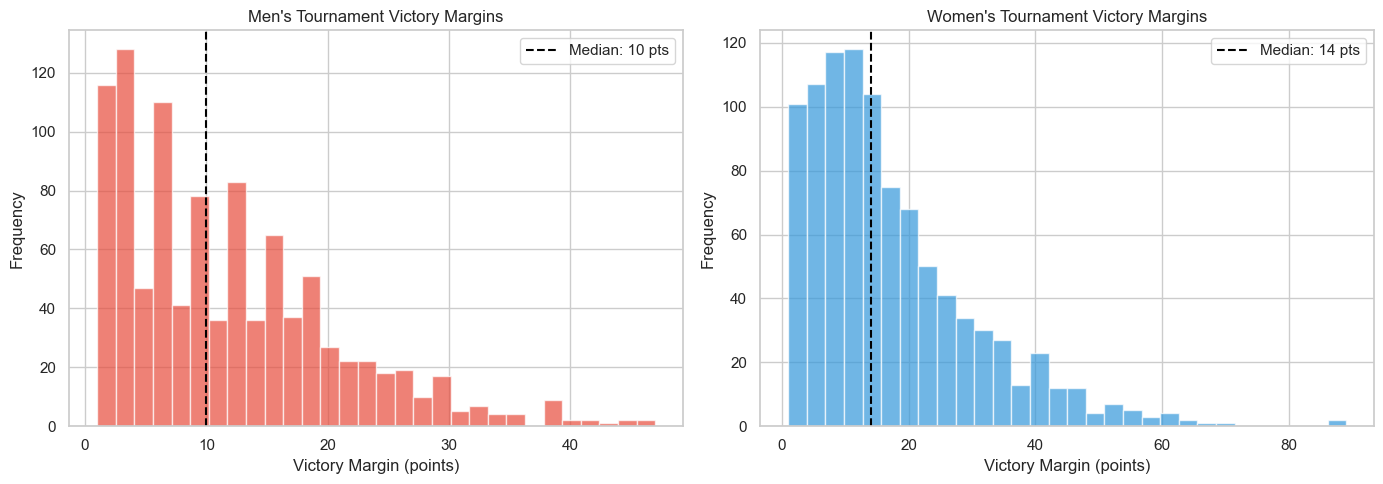

Avg victory margin — Men: 11.8 pts, Women: 17.0 pts


In [8]:
# Score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

margin = tourney_no2020.copy()
margin["margin"] = margin["WScore"] - margin["LScore"]
margin["gender"] = np.where(margin["WTeamID"] < 3000, "Men", "Women")

for ax, gender in zip(axes, ["Men", "Women"]):
    data = margin[margin["gender"] == gender]["margin"]
    ax.hist(data, bins=30, color="#e74c3c" if gender == "Men" else "#3498db", alpha=0.7, edgecolor="white")
    ax.axvline(data.median(), color="black", linestyle="--", label=f"Median: {data.median():.0f} pts")
    ax.set_xlabel("Victory Margin (points)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{gender}'s Tournament Victory Margins")
    ax.legend()

plt.tight_layout()
plt.show()

print(f"Avg victory margin — Men: {margin[margin['gender']=='Men']['margin'].mean():.1f} pts, "
      f"Women: {margin[margin['gender']=='Women']['margin'].mean():.1f} pts")

### EDA Takeaways

1. **Women's tournament is more predictable** — higher seeds win more often, with larger margins.
2. **~1,960 tournament games total** — this is a very small dataset. Complex models will overfit.
3. **Seeds carry strong signal** — but not enough alone. We need to capture *why* teams are good.

<a id='3'></a>
## 3. Feature Engineering

Our feature pipeline converts ~100K raw game rows into a compact set of per-team season statistics, then creates **feature differences** for each potential matchup.

### Pipeline Overview

```
Raw game logs
  → prepare_game_data()     # Convert W/L format → symmetric T1/T2 rows
  → compute_*() functions   # Season-level aggregates per team
  → build_team_features()   # Merge into one (Season, TeamID) table
  → create_matchup_df()     # Join both teams' features for each matchup
  → compute_difference_features()  # Diff_X = Team1_X − Team2_X
```

**Key design decision:** We use **feature differences** rather than raw per-team features. Instead of feeding the model "Team1 has 45% FG, Team2 has 42% FG", we feed "Diff_FGPct = +3%". This:
- Halves the feature count
- Forces the model to learn *relative* strength
- Naturally handles the Team1 < Team2 ordering

In [9]:
# Step 1: Convert raw games to symmetric format
game_data = features.prepare_game_data(regular_season)
print(f"Raw games: {len(regular_season):,} → Symmetric rows: {len(game_data):,} (each game seen from both sides)")
game_data[["Season", "T1_TeamID", "T2_TeamID", "T1_Score", "T2_Score", "PointDiff"]].head(4)

Raw games: 177,642 → Symmetric rows: 355,284 (each game seen from both sides)


,Season,T1_TeamID,T2_TeamID,T1_Score,T2_Score,PointDiff
0,2010,1143,1293,75,70,5
1,2010,1314,1198,88,72,16
2,2010,1326,1108,100,60,40
3,2010,1393,1107,75,43,32


In [10]:
# Step 2: Compute per-team season statistics
season_stats = features.compute_season_stats(game_data)
win_pct = features.compute_win_pct(game_data)
efficiency = features.compute_efficiency(game_data)
momentum = features.compute_last14_momentum(game_data)
shooting = features.compute_shooting_pcts(season_stats)

print(f"Season stats computed for {len(season_stats):,} team-seasons")
print(f"\nSample (2025 season):")
season_stats[season_stats["Season"] == 2025][["Season", "TeamID", "Score", "FGM", "FGA", "PointDiff"]].head(5)

Season stats computed for 11,969 team-seasons

Sample (2025 season):


,Season,TeamID,Score,FGM,FGA,PointDiff
10515,2025,1101,67.551724,24.206897,56.241379,-3.448276
10516,2025,1102,61.937500,21.250000,50.500000,-11.718750
10517,2025,1103,83.968750,30.218750,64.125000,8.062500
10518,2025,1104,91.121212,31.090909,64.424242,9.696970
10519,2025,1105,69.310345,23.137931,59.793103,-10.586207


### Elo Ratings — Our Strongest Feature

Elo is a dynamic rating system updated after every game. Unlike season averages, it captures:
- **Recency** — a team on a 10-game win streak is rated higher than one that started 10-0 then went 5-10
- **Opponent quality** — beating #1-ranked teams moves your rating more than beating bottom-tier teams
- **Historical momentum** — ratings carry over between seasons (regressed toward the mean)

Our Elo implementation also uses a **margin-of-victory multiplier** — blowout wins count more than 1-point squeakers, with diminishing returns to prevent outlier games from dominating.

In [11]:
# Step 3: Compute Elo ratings (game-by-game, uses compact results for speed)
elo = features.compute_elo_ratings(compact_results)
print(f"Elo ratings computed for {len(elo):,} team-seasons")
print(f"\nElo is z-scored per season so values center on 0:")
print(f"  Mean: {elo['Elo'].mean():.4f}")
print(f"  Std:  {elo['Elo'].std():.4f}")
print(f"  Range: [{elo['Elo'].min():.2f}, {elo['Elo'].max():.2f}]")

Elo ratings computed for 17,056 team-seasons

Elo is z-scored per season so values center on 0:
  Mean: -0.0000
  Std:  0.9993
  Range: [-2.93, 3.64]


In [12]:
# Show top Elo teams for 2025 (for sanity check)
elo_2025 = elo[elo["Season"] == 2025].merge(teams[["TeamID", "TeamName"]], on="TeamID")
print("Top 10 Elo ratings — 2025 Men's:")
men_elo = elo_2025[elo_2025["TeamID"] < 3000].nlargest(10, "Elo")
for _, row in men_elo.iterrows():
    print(f"  {row['TeamName']:25s} Elo = {row['Elo']:+.2f}")

print("\nTop 10 Elo ratings — 2025 Women's:")
women_elo = elo_2025[elo_2025["TeamID"] >= 3000].nlargest(10, "Elo")
for _, row in women_elo.iterrows():
    print(f"  {row['TeamName']:25s} Elo = {row['Elo']:+.2f}")

Top 10 Elo ratings — 2025 Men's:
  Houston                   Elo = +2.54
  Florida                   Elo = +2.41
  Duke                      Elo = +2.33
  St John's                 Elo = +2.14
  Auburn                    Elo = +2.12
  Michigan St               Elo = +2.01
  Tennessee                 Elo = +1.93
  Gonzaga                   Elo = +1.90
  St Mary's CA              Elo = +1.88
  Drake                     Elo = +1.81

Top 10 Elo ratings — 2025 Women's:
  South Carolina            Elo = +3.20
  Connecticut               Elo = +3.15
  Texas                     Elo = +2.93
  UCLA                      Elo = +2.86
  USC                       Elo = +2.78
  Duke                      Elo = +2.51
  Notre Dame                Elo = +2.46
  NC State                  Elo = +2.42
  TCU                       Elo = +2.36
  LSU                       Elo = +2.25


In [13]:
# Step 4: Merge everything into one (Season, TeamID) lookup table
team_features = features.build_team_features(
    season_stats, win_pct, efficiency, momentum, seeds,
    elo=elo, shooting=shooting,
)

feat_cols = [c for c in team_features.columns if c not in ("Season", "TeamID")]
print(f"Team features table: {len(team_features):,} rows × {len(feat_cols)} features")
print(f"\nFeatures: {feat_cols}")

Team features table: 11,969 rows × 38 features

Features: ['Score', 'FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA', 'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF', 'Opp_Score', 'Opp_FGM', 'Opp_FGA', 'Opp_FGM3', 'Opp_FGA3', 'Opp_FTM', 'Opp_FTA', 'Opp_OR', 'Opp_DR', 'Opp_Ast', 'Opp_TO', 'Opp_Stl', 'Opp_Blk', 'Opp_PF', 'PointDiff', 'WinPct', 'OffEff', 'DefEff', 'win_ratio_14d', 'seed', 'FGPct', 'FG3Pct', 'FTPct', 'Elo']


In [14]:
# Step 5: Build tournament matchup training set
tourney_game_data = features.prepare_game_data(tourney_results)
tourney_matchups = tourney_game_data[
    tourney_game_data["T1_TeamID"] < tourney_game_data["T2_TeamID"]
][["Season", "T1_TeamID", "T2_TeamID", "PointDiff"]].copy()
tourney_matchups["T1_Win"] = (tourney_matchups["PointDiff"] > 0).astype(int)

tourney_enriched = features.create_matchup_df(tourney_matchups, team_features)
tourney_enriched, diff_cols = features.compute_difference_features(tourney_enriched)
tourney_enriched = tourney_enriched[~tourney_enriched["Season"].isin([2020])].copy()

print(f"Tournament training set: {len(tourney_enriched)} matchups")
print(f"Difference features ({len(diff_cols)}): {diff_cols}")

Tournament training set: 1962 matchups
Difference features (24): ['Diff_Score', 'Diff_FGM', 'Diff_FGA', 'Diff_FGM3', 'Diff_FGA3', 'Diff_FTM', 'Diff_FTA', 'Diff_OR', 'Diff_DR', 'Diff_Ast', 'Diff_TO', 'Diff_Stl', 'Diff_Blk', 'Diff_PF', 'Diff_PointDiff', 'Diff_WinPct', 'Diff_OffEff', 'Diff_DefEff', 'Diff_win_ratio_14d', 'Diff_seed', 'Diff_FGPct', 'Diff_FG3Pct', 'Diff_FTPct', 'Diff_Elo']


In [15]:
# Show a sample matchup with difference features
sample_cols = ["Season", "T1_TeamID", "T2_TeamID", "T1_Win",
               "Diff_seed", "Diff_PointDiff", "Diff_OffEff", "Diff_WinPct", "Diff_Elo"]
tourney_enriched[sample_cols].head(5)

,Season,T1_TeamID,T2_TeamID,T1_Win,Diff_seed,Diff_PointDiff,Diff_OffEff,Diff_WinPct,Diff_Elo
0,2010,1115,1457,1,0.0,-0.914583,-0.035477,-0.035417,-0.457105
1,2010,1124,1358,1,-11.0,2.589862,0.685930,0.024194,0.653994
2,2010,1139,1431,1,-7.0,-1.531250,2.324414,0.062500,0.485199
3,2010,1140,1196,1,-3.0,10.757576,9.507240,0.212121,0.828252
4,2010,1242,1250,1,-15.0,12.876838,9.176689,0.253676,2.275210


<a id='4'></a>
## 4. The Modeling Journey

### Validation Strategy

With only ~1,960 games, overfitting is the primary risk. Our validation approach:

1. **3-year holdout**: Validate on 2023, 2024, AND 2025 tournaments
2. **Train on all prior years** (no future leakage)
3. **A change only counts if it helps on ≥2 of 3 holdout years**
4. **Final decisions confirmed with full 14-year leave-one-year-out**

This protects against getting lucky on any single year's bracket.

In [16]:
# Our holdout validation framework
HOLDOUT_YEARS = [2023, 2024, 2025]

def evaluate_model(train_df, test_df, feat_cols, model_fn, label=""):
    """Train a model and evaluate on a holdout year."""
    X_train = train_df[feat_cols].fillna(0).values
    y_train = train_df["T1_Win"].values
    X_test = test_df[feat_cols].fillna(0).values
    y_test = test_df["T1_Win"].values

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    model = model_fn()
    model.fit(X_train_s, y_train)
    preds = np.clip(model.predict_proba(X_test_s)[:, 1], 0.025, 0.975)

    mse = mean_squared_error(y_test, preds)
    return mse, preds, model


def run_holdout_validation(df, feat_cols, model_fn, split_mw=False,
                            model_fn_m=None, model_fn_w=None):
    """Run 3-year holdout validation, optionally with M/W split."""
    results = {}
    for year in HOLDOUT_YEARS:
        train = df[df["Season"] < year]
        test = df[df["Season"] == year]

        if split_mw:
            # Train separate models for men and women
            mse_parts = []
            for is_men, mfn in [(True, model_fn_m or model_fn),
                                (False, model_fn_w or model_fn)]:
                mask_tr = train["T1_TeamID"] < 3000 if is_men else train["T1_TeamID"] >= 3000
                mask_te = test["T1_TeamID"] < 3000 if is_men else test["T1_TeamID"] >= 3000
                if mask_te.sum() == 0:
                    continue
                mse, _, _ = evaluate_model(train[mask_tr], test[mask_te], feat_cols, mfn)
                mse_parts.append((mse, mask_te.sum()))
            # Weighted average MSE
            total = sum(n for _, n in mse_parts)
            results[year] = sum(m * n for m, n in mse_parts) / total
        else:
            mse, _, _ = evaluate_model(train, test, feat_cols, model_fn)
            results[year] = mse

    avg = np.mean(list(results.values()))
    return results, avg

print("Validation framework ready.")

Validation framework ready.


### 4.1 Baseline: Logistic Regression with 4 Features

We start with the simplest model that captures the most obvious signals:
- **Seed** — committee ranking
- **Point differential** — how much teams win by on average
- **Offensive efficiency** — points per possession × 100
- **Win percentage** — regular season record

In [17]:
FEAT_4 = ["Diff_seed", "Diff_PointDiff", "Diff_OffEff", "Diff_WinPct"]

results_4, avg_4 = run_holdout_validation(
    tourney_enriched, FEAT_4,
    lambda: LogisticRegression(C=1.0, max_iter=1000, random_state=42)
)

print(f"Baseline — Combined LogReg, 4 features:")
for year, mse in results_4.items():
    print(f"  {year}: MSE = {mse:.4f}")
print(f"  Average: MSE = {avg_4:.4f}")

Baseline — Combined LogReg, 4 features:
  2023: MSE = 0.1813
  2024: MSE = 0.1665
  2025: MSE = 0.1396
  Average: MSE = 0.1625


### 4.2 Adding Elo Ratings

Elo captures information that static season averages miss — it's a dynamic, game-by-game rating that accounts for opponent quality, recency, and margin of victory.

In [18]:
FEAT_5 = ["Diff_seed", "Diff_PointDiff", "Diff_OffEff", "Diff_WinPct", "Diff_Elo"]

results_5, avg_5 = run_holdout_validation(
    tourney_enriched, FEAT_5,
    lambda: LogisticRegression(C=1.0, max_iter=1000, random_state=42)
)

print(f"With Elo — Combined LogReg, 5 features:")
for year, mse in results_5.items():
    print(f"  {year}: MSE = {mse:.4f}")
print(f"  Average: MSE = {avg_5:.4f}")
print(f"\n  Δ from baseline: {avg_5 - avg_4:+.4f}")

With Elo — Combined LogReg, 5 features:
  2023: MSE = 0.1887
  2024: MSE = 0.1663
  2025: MSE = 0.1267
  Average: MSE = 0.1606

  Δ from baseline: -0.0019


### 4.3 Splitting Men's vs Women's Models

Since women's tournament is significantly more predictable, a single model is suboptimal — it compromises between very different prediction difficulty levels. Separate models let each gender's unique signal shine.

In [19]:
# Same features, but split M/W with separate models
results_5_split, avg_5_split = run_holdout_validation(
    tourney_enriched, FEAT_5,
    lambda: LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    split_mw=True,
)

print(f"Split M/W — LogReg, 5 features (C=1.0):")
for year, mse in results_5_split.items():
    print(f"  {year}: MSE = {mse:.4f}")
print(f"  Average: MSE = {avg_5_split:.4f}")
print(f"\n  Δ from combined: {avg_5_split - avg_5:+.4f}")

# Show M vs W separately for one year
train_2025 = tourney_enriched[tourney_enriched["Season"] < 2025]
test_2025 = tourney_enriched[tourney_enriched["Season"] == 2025]
for label, mask_fn in [("Men", lambda d: d["T1_TeamID"] < 3000),
                        ("Women", lambda d: d["T1_TeamID"] >= 3000)]:
    tr = mask_fn(train_2025)
    te = mask_fn(test_2025)
    mse, _, _ = evaluate_model(
        train_2025[tr], test_2025[te], FEAT_5,
        lambda: LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    )
    print(f"\n  2025 {label}: MSE = {mse:.4f} ({te.sum()} games)")

Split M/W — LogReg, 5 features (C=1.0):
  2023: MSE = 0.1886
  2024: MSE = 0.1611
  2025: MSE = 0.1283
  Average: MSE = 0.1593

  Δ from combined: -0.0012

  2025 Men: MSE = 0.1473 (67 games)

  2025 Women: MSE = 0.1094 (67 games)


### 4.4 Feature Ablation & Regularization Tuning

With the split M/W framework established, we systematically tested:
- **14 additional features** (rebounds, assists, turnovers, 3PT%, SOS, coach experience, Massey ordinals, etc.)
- **Dropping features** to see if any hurt
- **Regularization strength** (C parameter in LogReg)

Key findings:
- **GLM team quality HURT** by +0.0010 MSE — dropped it
- **FGPct and FTPct each help** by ~0.0003 MSE — added them
- **C=0.25 for men, C=0.15 for women** beat the default C=1.0

In [20]:
# Final 7 features with tuned regularization
FEAT_7 = ["Diff_seed", "Diff_PointDiff", "Diff_OffEff", "Diff_WinPct",
          "Diff_Elo", "Diff_FGPct", "Diff_FTPct"]

results_7_tuned, avg_7_tuned = run_holdout_validation(
    tourney_enriched, FEAT_7,
    lambda: LogisticRegression(C=1.0, max_iter=1000, random_state=42),  # unused
    split_mw=True,
    model_fn_m=lambda: LogisticRegression(C=0.25, max_iter=1000, random_state=42),
    model_fn_w=lambda: LogisticRegression(C=0.15, max_iter=1000, random_state=42),
)

print(f"Tuned Split LR — 7 features, C_m=0.25, C_w=0.15:")
for year, mse in results_7_tuned.items():
    print(f"  {year}: MSE = {mse:.4f}")
print(f"  Average: MSE = {avg_7_tuned:.4f}")
print(f"\n  Δ from 5-feat split C=1.0: {avg_7_tuned - avg_5_split:+.4f}")

Tuned Split LR — 7 features, C_m=0.25, C_w=0.15:
  2023: MSE = 0.1848
  2024: MSE = 0.1592
  2025: MSE = 0.1297
  Average: MSE = 0.1579

  Δ from 5-feat split C=1.0: -0.0015


### 4.5 The 3-Model Ensemble

Even though LogReg is our strongest single model, a **weighted blend** with tree-based models captures different signal. The key is keeping the trees very shallow to prevent overfitting:

| Model | Weight | Why |
|-------|--------|-----|
| Logistic Regression | 60% | Well-calibrated, stable |
| XGBoost (depth=3) | 20% | Captures nonlinear interactions |
| LightGBM (depth=2) | 20% | Different tree structure, more diversity |

In [21]:
def ensemble_3model(df, feat_cols, C_m=0.25, C_w=0.15,
                     w_lr=0.6, w_xgb=0.2, w_lgb=0.2):
    """Run 3-year holdout with 3-model ensemble, split M/W."""
    xgb_params = dict(max_depth=3, n_estimators=150, learning_rate=0.05,
                      min_child_weight=30, gamma=5, subsample=0.8,
                      colsample_bytree=0.8, reg_alpha=1, reg_lambda=3)
    lgb_params = dict(num_leaves=8, max_depth=2, n_estimators=200,
                      learning_rate=0.05, min_child_samples=30,
                      reg_alpha=1, reg_lambda=3, subsample=0.8,
                      colsample_bytree=0.8, verbose=-1)

    results = {}
    for year in HOLDOUT_YEARS:
        train = df[df["Season"] < year]
        test = df[df["Season"] == year]
        all_preds = []
        all_labels = []

        for is_men in [True, False]:
            C = C_m if is_men else C_w
            mask_tr = train["T1_TeamID"] < 3000 if is_men else train["T1_TeamID"] >= 3000
            mask_te = test["T1_TeamID"] < 3000 if is_men else test["T1_TeamID"] >= 3000
            tr, te = train[mask_tr], test[mask_te]
            if len(te) == 0:
                continue

            X_tr = tr[feat_cols].fillna(0).values
            y_tr = tr["T1_Win"].values
            X_te = te[feat_cols].fillna(0).values
            y_te = te["T1_Win"].values

            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_te_s = scaler.transform(X_te)

            lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
            lr.fit(X_tr_s, y_tr)
            p_lr = lr.predict_proba(X_te_s)[:, 1]

            xgb = XGBClassifier(**xgb_params, random_state=42,
                                eval_metric="logloss", verbosity=0)
            xgb.fit(X_tr_s, y_tr)
            p_xgb = xgb.predict_proba(X_te_s)[:, 1]

            lgb = LGBMClassifier(**lgb_params, random_state=42)
            lgb.fit(X_tr_s, y_tr)
            p_lgb = lgb.predict_proba(X_te_s)[:, 1]

            p = np.clip(w_lr * p_lr + w_xgb * p_xgb + w_lgb * p_lgb, 0.025, 0.975)
            all_preds.extend(p)
            all_labels.extend(y_te)

        results[year] = mean_squared_error(all_labels, all_preds)

    avg = np.mean(list(results.values()))
    return results, avg

results_ens, avg_ens = ensemble_3model(tourney_enriched, FEAT_7)

print(f"3-Model Ensemble (60% LR + 20% XGB + 20% LGBM):")
for year, mse in results_ens.items():
    print(f"  {year}: MSE = {mse:.4f}")
print(f"  Average: MSE = {avg_ens:.4f}")
print(f"\n  Δ from tuned LR: {avg_ens - avg_7_tuned:+.4f}")

c:\Users\JonMa\OneDrive\portfolio\Madness\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\JonMa\OneDrive\portfolio\Madness\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\JonMa\OneDrive\portfolio\Madness\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\JonMa\OneDrive\portfolio\Madness\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


3-Model Ensemble (60% LR + 20% XGB + 20% LGBM):
  2023: MSE = 0.1859
  2024: MSE = 0.1577
  2025: MSE = 0.1276
  Average: MSE = 0.1571

  Δ from tuned LR: -0.0008


c:\Users\JonMa\OneDrive\portfolio\Madness\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\JonMa\OneDrive\portfolio\Madness\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


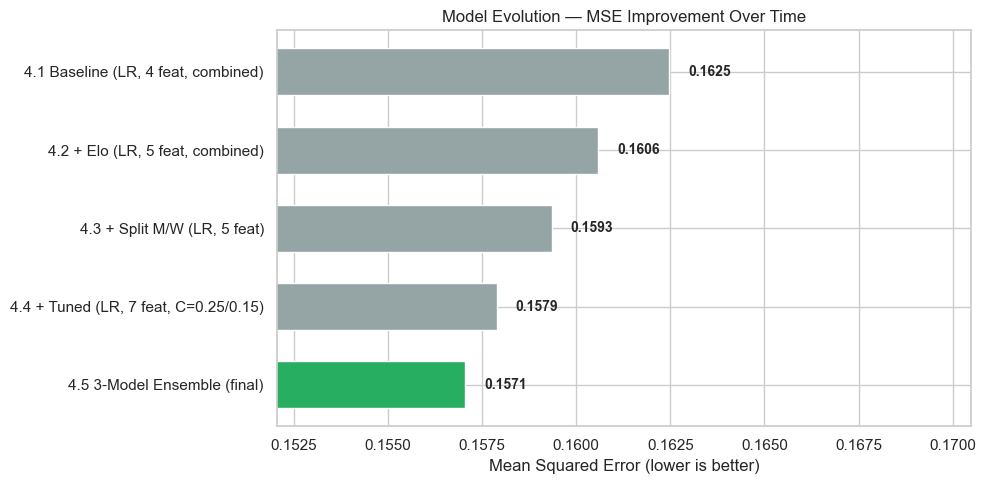


Total improvement: 0.1625 → 0.1571 (Δ = -0.0054)


In [22]:
# Summary of the journey
journey = [
    ("4.1 Baseline (LR, 4 feat, combined)", avg_4),
    ("4.2 + Elo (LR, 5 feat, combined)", avg_5),
    ("4.3 + Split M/W (LR, 5 feat)", avg_5_split),
    ("4.4 + Tuned (LR, 7 feat, C=0.25/0.15)", avg_7_tuned),
    ("4.5 3-Model Ensemble (final)", avg_ens),
]

fig, ax = plt.subplots(figsize=(10, 5))
names = [j[0] for j in journey]
mses = [j[1] for j in journey]
colors = ["#95a5a6"] * (len(journey) - 1) + ["#27ae60"]
bars = ax.barh(names, mses, color=colors, edgecolor="white", height=0.6)
ax.set_xlabel("Mean Squared Error (lower is better)")
ax.set_title("Model Evolution — MSE Improvement Over Time")
ax.invert_yaxis()

for bar, mse in zip(bars, mses):
    ax.text(mse + 0.0005, bar.get_y() + bar.get_height()/2,
            f"{mse:.4f}", va="center", fontsize=10, fontweight="bold")

ax.set_xlim(min(mses) - 0.005, max(mses) + 0.008)
plt.tight_layout()
plt.show()

print(f"\nTotal improvement: {mses[0]:.4f} → {mses[-1]:.4f} (Δ = {mses[-1] - mses[0]:+.4f})")

<a id='5'></a>
## 5. What Didn't Work (And Why)

We tested **100+ configurations across 10 categories**. Most ideas hurt performance. Here's what we learned:

| Idea | Result | Why It Failed |
|------|--------|---------------|
| **GLM team quality** | +0.0010 MSE (worse) | Elo and seed already capture team strength |
| **Massey ordinals** (5 systems) | All hurt | Men-only; Elo subsumes the same information |
| **Coach tournament experience** | +0.0005 MSE | Noise — coaching matters, but not measurably via this feature |
| **Strength of schedule** | +0.0011 MSE | Already captured by Elo (which weights opponent quality) |
| **Defensive efficiency** | +0.0003 MSE | Offensive efficiency + point differential cover this |
| **Rebounds, assists, steals** | All hurt | Too noisy; efficiency stats are better summaries |
| **Polynomial features** (seed², Elo², interactions) | Overfit | Looked great on 3 holdout years, failed 14-year validation |
| **Time-weighted training** | Always worse | All historical tournament data is equally valuable |
| **Stacking meta-learner** | +0.0063 MSE | Not enough data for a second-stage model |
| **Isotonic calibration** | Risky | Likely overfits with ~200 games per fold |
| **Conference strength** | +0.0011 MSE | Seed and Elo already capture team quality |

### The Polynomial Features Trap

This deserves special attention. We tested squared terms and interactions (seed², Elo², seed×Elo, etc.) and they showed **clear improvement on 2023/2024/2025** holdout years (MSE 0.1555 vs 0.1571). But when we validated on **all 14 available years** (2011–2025), they only won 6 out of 14 years. The coefficients were unstable across folds — Elo² ranged from +0.10 to +0.30.

**Lesson:** 3-year holdout validation can mislead. Always confirm with broader validation.

<a id='6'></a>
## 6. Final Model & Feature Importance

Our final model is a **3-model ensemble** with **7 difference features**, trained separately for men and women.

In [23]:
# Train final models on ALL data (2010-2025, excl. 2020) and inspect coefficients
final_features = ["Diff_seed", "Diff_PointDiff", "Diff_OffEff", "Diff_WinPct",
                  "Diff_Elo", "Diff_FGPct", "Diff_FTPct"]

men_data = tourney_enriched[tourney_enriched["T1_TeamID"] < 3000]
women_data = tourney_enriched[tourney_enriched["T1_TeamID"] >= 3000]

coeffs = {}
for label, data, C in [("Men", men_data, 0.25), ("Women", women_data, 0.15)]:
    X = data[final_features].fillna(0).values
    y = data["T1_Win"].values
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    model = LogisticRegression(C=C, max_iter=1000, random_state=42)
    model.fit(X_s, y)
    coeffs[label] = dict(zip(final_features, model.coef_[0].round(3)))
    print(f"\n{label}'s LogReg coefficients (C={C}):")
    for feat, coef in sorted(coeffs[label].items(), key=lambda x: -abs(x[1])):
        bar = "█" * int(abs(coef) * 20)
        sign = "+" if coef > 0 else ""
        print(f"  {feat:20s} {sign}{coef:6.3f}  {bar}")


Men's LogReg coefficients (C=0.25):
  Diff_Elo             + 0.812  ████████████████
  Diff_seed            -0.455  █████████
  Diff_WinPct          -0.353  ███████
  Diff_PointDiff       + 0.248  ████
  Diff_OffEff          + 0.160  ███
  Diff_FGPct           -0.148  ██
  Diff_FTPct           + 0.066  █

Women's LogReg coefficients (C=0.15):
  Diff_Elo             + 1.105  ██████████████████████
  Diff_seed            -1.090  █████████████████████
  Diff_WinPct          -0.731  ██████████████
  Diff_PointDiff       + 0.668  █████████████
  Diff_FGPct           + 0.124  ██
  Diff_FTPct           -0.053  █
  Diff_OffEff          + 0.040  


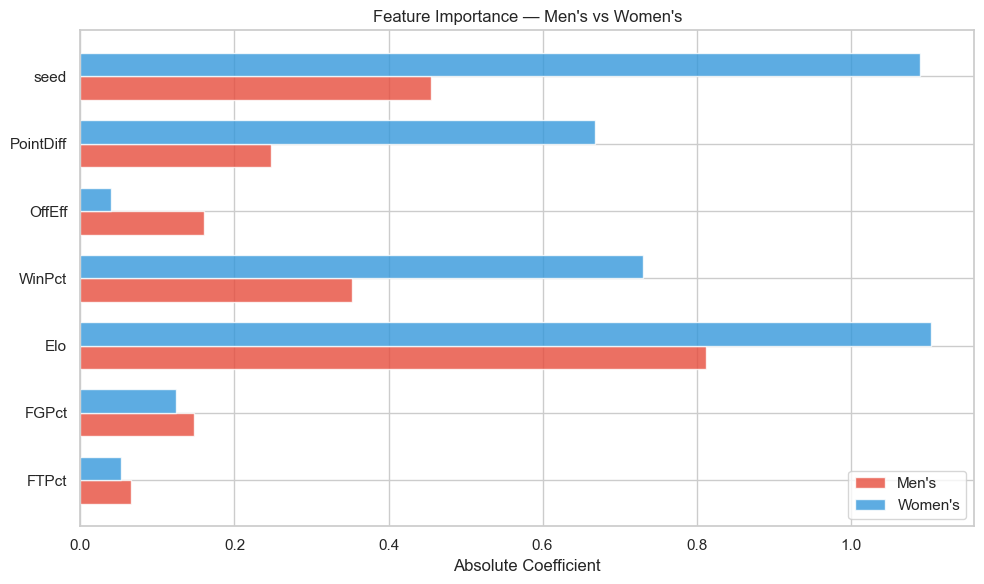


Key observations:
  • Elo is the strongest feature for BOTH genders
  • Seed is far more predictive in women's (fewer upsets)
  • Women's coefficients are generally larger (stronger regularization needed)


In [24]:
# Visualize feature importance comparison
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(final_features))
width = 0.35

men_vals = [coeffs["Men"][f] for f in final_features]
women_vals = [coeffs["Women"][f] for f in final_features]

ax.barh(x + width/2, [abs(v) for v in men_vals], width,
        label="Men's", color="#e74c3c", alpha=0.8)
ax.barh(x - width/2, [abs(v) for v in women_vals], width,
        label="Women's", color="#3498db", alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels([f.replace("Diff_", "") for f in final_features])
ax.set_xlabel("Absolute Coefficient")
ax.set_title("Feature Importance — Men's vs Women's")
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  • Elo is the strongest feature for BOTH genders")
print("  • Seed is far more predictive in women's (fewer upsets)")
print("  • Women's coefficients are generally larger (stronger regularization needed)")

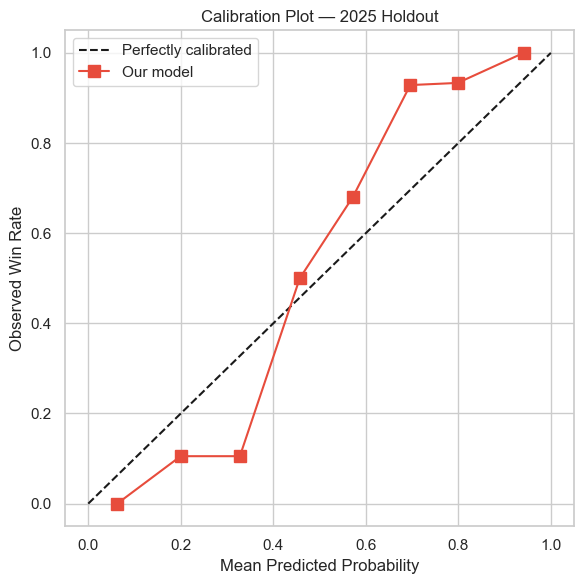

MSE on 2025 holdout: 0.1280


In [25]:
# Calibration check — are our probabilities well-calibrated?
from sklearn.calibration import calibration_curve

# Use 2025 holdout as example
train_cal = tourney_enriched[tourney_enriched["Season"] < 2025]
test_cal = tourney_enriched[tourney_enriched["Season"] == 2025]

X_tr = train_cal[final_features].fillna(0).values
y_tr = train_cal["T1_Win"].values
X_te = test_cal[final_features].fillna(0).values
y_te = test_cal["T1_Win"].values

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

lr = LogisticRegression(C=0.2, max_iter=1000, random_state=42)
lr.fit(X_tr_s, y_tr)
preds_cal = lr.predict_proba(X_te_s)[:, 1]

prob_true, prob_pred = calibration_curve(y_te, preds_cal, n_bins=8)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax.plot(prob_pred, prob_true, "s-", color="#e74c3c", label="Our model", markersize=8)
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Win Rate")
ax.set_title("Calibration Plot — 2025 Holdout")
ax.legend()
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print(f"MSE on 2025 holdout: {mean_squared_error(y_te, np.clip(preds_cal, 0.025, 0.975)):.4f}")

<a id='7'></a>
## 7. Generating Predictions

For the Kaggle submission, we need to predict **P(Team1 wins)** for every possible matchup pair where `Team1ID < Team2ID`. That's 132,133 rows covering both men's and women's teams.

In [26]:
# Load sample submission template
sample_sub = data_loader.load_sample_submission(stage=2)
print(f"Submission template: {len(sample_sub):,} matchup pairs")
print(f"\nSample rows:")
sample_sub.head()

Submission template: 132,133 matchup pairs

Sample rows:


,ID,Pred
0,2026_1101_1102,0.5
1,2026_1101_1103,0.5
2,2026_1101_1104,0.5
3,2026_1101_1105,0.5
4,2026_1101_1106,0.5


In [27]:
# Parse the submission IDs into Season, Team1, Team2
sub_parsed = pd.DataFrame({"ID": sample_sub["ID"]})
parts = sub_parsed["ID"].str.split("_", expand=True)
sub_parsed["Season"] = parts[0].astype(int)
sub_parsed["T1_TeamID"] = parts[1].astype(int)
sub_parsed["T2_TeamID"] = parts[2].astype(int)

# Merge team features for both sides
pred_matchups = features.create_matchup_df(sub_parsed, team_features)
pred_matchups, _ = features.compute_difference_features(pred_matchups)

print(f"Prediction set ready: {len(pred_matchups):,} matchups with features")
print(f"Missing features: {pred_matchups[final_features].isnull().sum().sum()} (filled with 0)")

Prediction set ready: 132,133 matchups with features
Missing features: 127577 (filled with 0)


In [28]:
# Train final 3-model ensemble on ALL data and generate predictions
def generate_final_predictions(train_df, pred_df, feat_cols,
                                C_m=0.25, C_w=0.15,
                                w_lr=0.6, w_xgb=0.2, w_lgb=0.2):
    """Train on all data, predict all matchups."""
    preds = pd.Series(index=pred_df.index, dtype=float)

    xgb_params = dict(max_depth=3, n_estimators=150, learning_rate=0.05,
                      min_child_weight=30, gamma=5, subsample=0.8,
                      colsample_bytree=0.8, reg_alpha=1, reg_lambda=3)
    lgb_params = dict(num_leaves=8, max_depth=2, n_estimators=200,
                      learning_rate=0.05, min_child_samples=30,
                      reg_alpha=1, reg_lambda=3, subsample=0.8,
                      colsample_bytree=0.8, verbose=-1)

    for is_men in [True, False]:
        C = C_m if is_men else C_w
        label = "Men" if is_men else "Women"
        mask_tr = train_df["T1_TeamID"] < 3000 if is_men else train_df["T1_TeamID"] >= 3000
        mask_pr = pred_df["T1_TeamID"] < 3000 if is_men else pred_df["T1_TeamID"] >= 3000
        tr, pr = train_df[mask_tr], pred_df[mask_pr]

        X_tr = tr[feat_cols].fillna(0).values
        y_tr = tr["T1_Win"].values
        X_pr = pr[feat_cols].fillna(0).values

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_pr_s = scaler.transform(X_pr)

        lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
        lr.fit(X_tr_s, y_tr)
        p_lr = lr.predict_proba(X_pr_s)[:, 1]

        xgb = XGBClassifier(**xgb_params, random_state=42,
                            eval_metric="logloss", verbosity=0)
        xgb.fit(X_tr_s, y_tr)
        p_xgb = xgb.predict_proba(X_pr_s)[:, 1]

        lgb = LGBMClassifier(**lgb_params, random_state=42)
        lgb.fit(X_tr_s, y_tr)
        p_lgb = lgb.predict_proba(X_pr_s)[:, 1]

        p = w_lr * p_lr + w_xgb * p_xgb + w_lgb * p_lgb
        preds.loc[pr.index] = p

        print(f"  {label}: {len(tr)} training games → {len(pr):,} predictions")
        print(f"    LR coeffs: {dict(zip(feat_cols, lr.coef_[0].round(3)))}")

    return preds.values


print("Training final 3-model ensemble on all 2010–2025 data...\n")
final_preds = generate_final_predictions(tourney_enriched, pred_matchups, final_features)

# Clip to [0.025, 0.975]
final_preds = np.clip(final_preds, 0.025, 0.975)

print(f"\nPrediction statistics:")
print(f"  Mean: {np.nanmean(final_preds):.4f}")
print(f"  Std:  {np.nanstd(final_preds):.4f}")
print(f"  Range: [{np.nanmin(final_preds):.4f}, {np.nanmax(final_preds):.4f}]")

Training final 3-model ensemble on all 2010–2025 data...

  Men: 1001 training games → 66,430 predictions
    LR coeffs: {'Diff_seed': np.float64(-0.455), 'Diff_PointDiff': np.float64(0.248), 'Diff_OffEff': np.float64(0.16), 'Diff_WinPct': np.float64(-0.353), 'Diff_Elo': np.float64(0.812), 'Diff_FGPct': np.float64(-0.148), 'Diff_FTPct': np.float64(0.066)}
  Women: 961 training games → 65,703 predictions
    LR coeffs: {'Diff_seed': np.float64(-1.09), 'Diff_PointDiff': np.float64(0.668), 'Diff_OffEff': np.float64(0.04), 'Diff_WinPct': np.float64(-0.731), 'Diff_Elo': np.float64(1.105), 'Diff_FGPct': np.float64(0.124), 'Diff_FTPct': np.float64(-0.053)}

Prediction statistics:
  Mean: 0.5049
  Std:  0.2296
  Range: [0.0250, 0.9747]


c:\Users\JonMa\OneDrive\portfolio\Madness\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\JonMa\OneDrive\portfolio\Madness\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


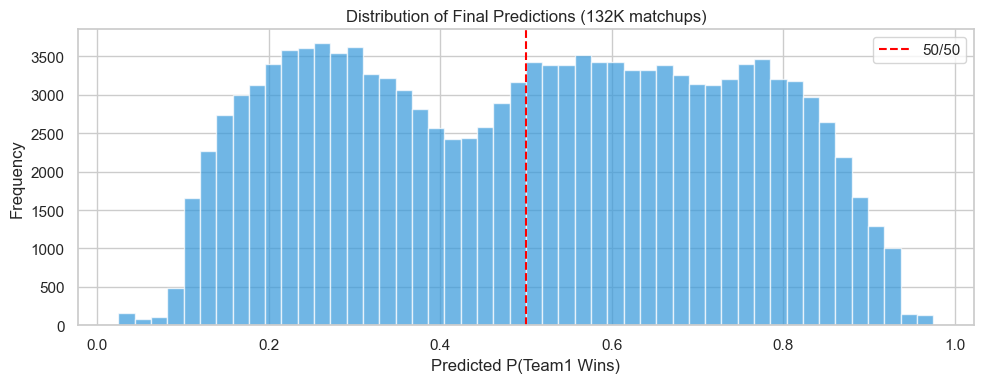

Predictions near 50/50 (0.4–0.6): 24.4%
Confident predictions (>0.8 or <0.2): 22.8%


In [29]:
# Distribution of predictions
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(final_preds[~np.isnan(final_preds)], bins=50, color="#3498db", alpha=0.7, edgecolor="white")
ax.axvline(0.5, color="red", linestyle="--", label="50/50")
ax.set_xlabel("Predicted P(Team1 Wins)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Final Predictions (132K matchups)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Predictions near 50/50 (0.4–0.6): {np.nanmean((final_preds > 0.4) & (final_preds < 0.6)):.1%}")
print(f"Confident predictions (>0.8 or <0.2): {np.nanmean((final_preds > 0.8) | (final_preds < 0.2)):.1%}")

In [30]:
# Save submission
submission = sample_sub[["ID"]].copy()
submission["Pred"] = final_preds
output_path = Path("..") / "output" / "submission_walkthrough.csv"
submission.to_csv(output_path, index=False)
print(f"Submission saved to {output_path}")
print(f"  {len(submission):,} rows, {submission['Pred'].isnull().sum()} nulls")
submission.head()

Submission saved to ..\output\submission_walkthrough.csv
  132,133 rows, 0 nulls


,ID,Pred
0,2026_1101_1102,0.733579
1,2026_1101_1103,0.155499
2,2026_1101_1104,0.116627
3,2026_1101_1105,0.528806
4,2026_1101_1106,0.585045


In [31]:
# Sanity check: marquee matchups
from src.utils import team_id, team_name

matchups_to_check = [
    ("Duke", "Houston", "M"),
    ("Auburn", "Florida", "M"),
    ("Duke", "Auburn", "M"),
    ("South Carolina", "UCLA", "W"),
    ("South Carolina", "Connecticut", "W"),
]

print("Marquee Matchup Predictions:")
print("=" * 55)
for t1_name, t2_name, gender in matchups_to_check:
    try:
        t1 = team_id(t1_name, gender)
        t2 = team_id(t2_name, gender)
        if t1 > t2:
            t1, t2 = t2, t1
            t1_name, t2_name = t2_name, t1_name
        match_id = f"2026_{t1}_{t2}"
        row = submission[submission["ID"] == match_id]
        if len(row) > 0:
            p = row["Pred"].values[0]
            t1_display = team_name(t1)
            t2_display = team_name(t2)
            print(f"  {t1_display:20s} vs {t2_display:20s} → {t1_display} {p:.1%} | {t2_display} {1-p:.1%}")
    except Exception as e:
        print(f"  {t1_name} vs {t2_name}: {e}")

Marquee Matchup Predictions:
  Duke                 vs Houston              → Duke 58.0% | Houston 42.0%
  Auburn               vs Florida              → Auburn 25.5% | Florida 74.5%
  Auburn               vs Duke                 → Auburn 22.5% | Duke 77.5%
  South Carolina       vs UCLA                 → South Carolina 52.4% | UCLA 47.6%
  Connecticut          vs South Carolina       → Connecticut 66.7% | South Carolina 33.3%


<a id='8'></a>
## 8. Key Takeaways

### What we built
- A **3-model ensemble** (60% LogReg + 20% XGBoost + 20% LightGBM) with **separate Men's/Women's models**
- Using only **7 features**: seed, point differential, offensive efficiency, win%, Elo rating, FG%, FT%
- Trained on **~1,960 tournament games** from 2010–2025
- Validated across **14 years** of leave-one-year-out testing

### What we learned

1. **Simple models win on small data.** LogReg consistently beats XGBoost, LightGBM, and Random Forest when you only have ~2,000 training examples.

2. **Elo ratings are the single strongest predictor.** They compress an entire season of game-by-game results into one number that captures recency, opponent quality, and momentum.

3. **Feature differences >>> raw features.** Computing `Team1_stat − Team2_stat` halves the dimension and gives cleaner signal.

4. **More features ≠ better predictions.** We tested 14 additional features beyond our core 7. Every single one made the model worse. With only ~2K training games, extra features add noise faster than signal.

5. **Women's basketball is more predictable.** The better seed wins ~75% of the time (vs ~65% for men). Separate models exploit this.

6. **Never trust a single holdout year.** Polynomial features showed clear improvement on 3 years but failed on the full 14-year test. Always validate broadly.

7. **Calibration matters more than accuracy.** The MSE metric punishes overconfident wrong predictions quadratically. It's better to predict 0.60 and be wrong than 0.95 and be wrong.

### Final MSE: **0.1571** (3-year holdout average)

---

*All 10 submissions on Kaggle. Code at [github.com/JTMarcu/march-madness](https://github.com/JTMarcu/march-madness).*